# Huấn luyện & So sánh Model — Phân loại tổn thương da (HAM10000)

Notebook này huấn luyện **3 kiến trúc** (EfficientNet-B0, ResNet50, MobileNetV3-Large) trên dataset **HAM10000**, đồng thời dựng sẵn **câu chuyện cải thiện model `v1` → `v2`** phục vụ phần demo retraining / promote của hệ thống MLOps.

## Yêu cầu môi trường Kaggle
- **Accelerator**: GPU P100 (Settings → Accelerator → GPU P100)
- **Internet**: ON (Settings → Internet → On) để torchvision tải pretrained weights
- **Dataset**: attach dataset HAM10000 (ví dụ `skin-cancer-mnist-ham10000`). Notebook tự dò đường dẫn trong `/kaggle/input`.

## Câu chuyện thí nghiệm `v1` vs `v2`

| Yếu tố | `v1` (baseline yếu — cố ý) | `v2` (cải thiện) |
|---|---|---|
| Train data | 30% train set, giữ mất cân bằng | 100% train set |
| Backbone | Freeze (chỉ train head) | Fine-tune toàn bộ |
| Xử lý imbalance | Không | Weighted loss `sqrt(1/freq)` |
| Augmentation | Tối thiểu | Đầy đủ |
| Scheduler | Không | CosineAnnealingLR |
| Epochs / LR | 5 / 1e-3 | 18 / 5e-4 |
| Test set | Đóng băng (giống hệt) | Đóng băng (giống hệt) |

Mục tiêu: `v2` thắng `v1` **toàn diện** (macro-F1, macro-recall, melanoma recall) mà accuracy không tụt thảm — làm bằng chứng cho promote gate. `v1` được làm yếu rõ ràng (ít data + freeze backbone) để khoảng cách v1→v2 đủ lớn; `v2` chỉ dùng **một** cơ chế cân bằng (weighted loss nhẹ tay `sqrt`) để tránh over-correct làm sập accuracy lớp đa số.

## 1. Import

In [1]:
import os
import json
import glob
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    ResNet50_Weights,
    MobileNet_V3_Large_Weights,
)
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.__version__)

cpu
2.10.0+cpu


## 2. Cấu hình (CONFIG)

Toàn bộ tham số gom về đây. Đổi `MODELS_TO_RUN` hoặc `RUN_VERSIONS` để chạy ít/nhiều hơn.

In [2]:
SEED = 42

INPUT_ROOT = None
WORK_DIR = "/kaggle/working"

CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
DANGER_CLASS = "mel"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

RUN_TRAINING = False

MODELS_TO_RUN = ["efficientnet_b0", "resnet50", "mobilenet_v3_large"]
RUN_VERSIONS = ["v1", "v2"]

EPOCHS = {"v1": 5, "v2": 18}
LR = {"v1": 1e-3, "v2": 5e-4}

V1_TRAIN_FRACTION = 0.3
TEST_SIZE = 0.15
VAL_SIZE = 0.15

USE_AMP = True

ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_LABEL = {i: c for c, i in LABEL_TO_IDX.items()}

## 3. Dò dataset & nạp metadata

Tự tìm `HAM10000_metadata.csv` và lập chỉ mục mọi ảnh `.jpg` trong `/kaggle/input` để không phụ thuộc tên dataset cụ thể.

In [3]:
def find_metadata():
    hits = glob.glob("/kaggle/input/**/HAM10000_metadata.csv", recursive=True)
    if not hits:
        hits = glob.glob("/kaggle/input/**/*metadata*.csv", recursive=True)
    if not hits:
        raise FileNotFoundError("Khong tim thay HAM10000_metadata.csv trong /kaggle/input")
    return hits[0]

def build_image_index():
    paths = glob.glob("/kaggle/input/**/*.jpg", recursive=True)
    index = {}
    for p in paths:
        stem = os.path.splitext(os.path.basename(p))[0]
        index[stem] = p
    return index

META_PATH = find_metadata()
IMAGE_INDEX = build_image_index()
print(META_PATH)
print("So anh tim duoc:", len(IMAGE_INDEX))

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
So anh tim duoc: 10015


In [4]:
meta = pd.read_csv(META_PATH)
meta = meta[meta["image_id"].isin(IMAGE_INDEX.keys())].copy()
meta["path"] = meta["image_id"].map(IMAGE_INDEX)
meta["label"] = meta["dx"]
meta = meta[meta["label"].isin(CLASSES)].reset_index(drop=True)
print(meta.shape)
meta["label"].value_counts()

(10015, 9)


label
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

## 4. EDA nhanh — phân phối lớp

HAM10000 mất cân bằng nặng (`nv` chiếm phần lớn). Đây chính là lý do `v1` không xử lý imbalance sẽ yếu ở các lớp hiếm như `mel`.

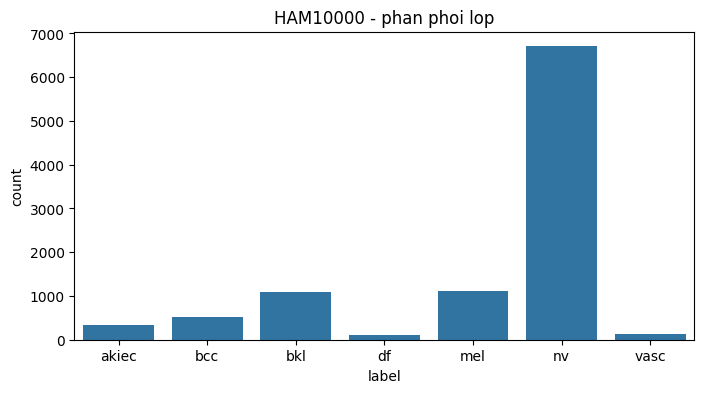

label
akiec    0.0327
bcc      0.0513
bkl      0.1097
df       0.0115
mel      0.1111
nv       0.6695
vasc     0.0142
Name: proportion, dtype: float64

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=meta, x="label", order=CLASSES)
plt.title("HAM10000 - phan phoi lop")
plt.show()

meta["label"].value_counts(normalize=True).reindex(CLASSES).round(4)

## 5. Chia train / val / test theo `lesion_id` (đóng băng)

Chia theo `lesion_id` để tránh rò rỉ (cùng một tổn thương xuất hiện ở cả train lẫn test). Test set cố định bằng `SEED` và dùng chung cho mọi model/version.

In [6]:
def make_splits(df):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    trainval_idx, test_idx = next(gss1.split(df, groups=df["lesion_id"]))
    df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)
    rel_val = VAL_SIZE / (1.0 - TEST_SIZE)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=rel_val, random_state=SEED)
    train_idx, val_idx = next(gss2.split(df_trainval, groups=df_trainval["lesion_id"]))
    df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_val = df_trainval.iloc[val_idx].reset_index(drop=True)
    return df_train, df_val, df_test

df_train_full, df_val, df_test = make_splits(meta)
print("train/val/test:", len(df_train_full), len(df_val), len(df_test))

assert set(df_train_full["lesion_id"]) & set(df_test["lesion_id"]) == set()
assert set(df_val["lesion_id"]) & set(df_test["lesion_id"]) == set()
assert set(df_train_full["lesion_id"]) & set(df_val["lesion_id"]) == set()
print("Khong co ro ri lesion_id giua cac tap.")

train/val/test: 6959 1529 1527
Khong co ro ri lesion_id giua cac tap.


## 5.1. Xuất ảnh test cho demo

Lưu danh sách ảnh test (`test_images.csv`), copy 10 ảnh mỗi lớp vào `demo_samples/` và nén thành `demo_samples.zip`. Tên file đặt dạng `{label}__{image_id}.jpg` để biết ngay nhãn đúng khi demo. Test set này cố định theo `SEED`, là ảnh model CHƯA thấy lúc train.

Với `RUN_TRAINING=False` (mặc định ở cell config), bạn có thể **Run All** — notebook bỏ qua training, chạy nhanh tới đây và sinh `demo_samples.zip` để tải về. Muốn train lại thì đặt `RUN_TRAINING=True`.

In [7]:
import shutil

DEMO_DIR = os.path.join(WORK_DIR, "demo_samples")
os.makedirs(DEMO_DIR, exist_ok=True)

df_test[["image_id", "label", "path"]].to_csv(os.path.join(WORK_DIR, "test_images.csv"), index=False)

N_PER_CLASS = 10
for cls in CLASSES:
    subset = df_test[df_test["label"] == cls].head(N_PER_CLASS)
    for _, row in subset.iterrows():
        dst = os.path.join(DEMO_DIR, f"{cls}__{row['image_id']}.jpg")
        shutil.copy(row["path"], dst)

zip_path = shutil.make_archive(os.path.join(WORK_DIR, "demo_samples"), "zip", DEMO_DIR)

print("Da luu danh sach test:", os.path.join(WORK_DIR, "test_images.csv"))
print("Anh demo (", N_PER_CLASS, "moi lop ):", DEMO_DIR)
print("File nen de tai ve:", zip_path)
print(df_test["label"].value_counts())

Da luu danh sach test: /kaggle/working/test_images.csv
Anh demo ( 10 moi lop ): /kaggle/working/demo_samples
File nen de tai ve: /kaggle/working/demo_samples.zip
label
nv       1016
mel       186
bkl       172
bcc        66
akiec      48
vasc       29
df         10
Name: count, dtype: int64


## 6. Thiết lập dữ liệu cho `v1` và `v2`

`v1` chỉ dùng 30% train set (lấy ngẫu nhiên, giữ nguyên mất cân bằng). `v2` dùng toàn bộ train set.

In [8]:
df_train_v1 = df_train_full.sample(frac=V1_TRAIN_FRACTION, random_state=SEED).reset_index(drop=True)
df_train_v2 = df_train_full.copy()
print("v1 train:", len(df_train_v1), "| v2 train:", len(df_train_v2))

v1 train: 2088 | v2 train: 6959


## 7. Transforms

`v1` dùng transform tối thiểu. `v2` dùng augmentation đầy đủ. Val/test luôn dùng transform đánh giá cố định.

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

tf_eval = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tf_minimal = tf_eval

tf_augment = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 8. Dataset

In [10]:
class LesionDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].tolist()
        self.labels = [LABEL_TO_IDX[x] for x in df["label"].tolist()]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]

## 9. DataLoader theo version

`v2` chỉ dùng **một** cơ chế cân bằng: weighted loss với trọng số `sqrt(1/freq)` (nhẹ tay hơn `1/freq` để không đè chết lớp đa số `nv`). `v1` không có gì. Cả hai đều `shuffle=True`.

In [11]:
def class_weights_from(df):
    labels = df["label"].map(LABEL_TO_IDX).values
    counts = np.bincount(labels, minlength=len(CLASSES))
    weights = 1.0 / np.sqrt(np.maximum(counts, 1))
    weights = weights / weights.sum() * len(CLASSES)
    return torch.tensor(weights, dtype=torch.float32)

def build_loaders(version):
    if version == "v1":
        train_df = df_train_v1
        train_ds = LesionDataset(train_df, tf_minimal)
        ce_weight = None
    else:
        train_df = df_train_v2
        train_ds = LesionDataset(train_df, tf_augment)
        ce_weight = class_weights_from(train_df).to(device)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(LesionDataset(df_val, tf_eval), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(LesionDataset(df_test, tf_eval), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader, ce_weight

## 10. Build model (chọn theo config)

Dùng torchvision pretrained ImageNet, thay head cho 7 lớp. `freeze_backbone=True` (dùng cho `v1`) sẽ đóng băng toàn bộ backbone, chỉ huấn luyện head → baseline yếu có chủ đích.

In [12]:
def build_model(name, freeze_backbone=False):
    if name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_f, len(CLASSES))
        head = m.classifier[1]
    elif name == "resnet50":
        m = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_f = m.fc.in_features
        m.fc = nn.Linear(in_f, len(CLASSES))
        head = m.fc
    elif name == "mobilenet_v3_large":
        m = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        in_f = m.classifier[3].in_features
        m.classifier[3] = nn.Linear(in_f, len(CLASSES))
        head = m.classifier[3]
    else:
        raise ValueError(name)
    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False
        for p in head.parameters():
            p.requires_grad = True
    return m.to(device)

## 11. Hàm train / đánh giá / tính metric

Metric theo plan: accuracy, macro-F1, weighted-F1, precision/recall macro, top-3 accuracy, và **melanoma recall** (lớp nguy hiểm).

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total = 0.0
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        if USE_AMP and device.type == "cuda":
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        total += loss.item() * images.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    all_probs = []
    all_targets = []
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(targets.numpy())
    return np.concatenate(all_probs), np.concatenate(all_targets)

def compute_metrics(probs, targets):
    preds = probs.argmax(axis=1)
    top3 = np.argsort(probs, axis=1)[:, -3:]
    top3_acc = float(np.mean([t in row for t, row in zip(targets, top3)]))
    mel_idx = LABEL_TO_IDX[DANGER_CLASS]
    rec_per_class = recall_score(targets, preds, average=None, labels=list(range(len(CLASSES))), zero_division=0)
    metrics = {
        "accuracy": float(accuracy_score(targets, preds)),
        "f1_macro": float(f1_score(targets, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(targets, preds, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(targets, preds, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(targets, preds, average="macro", zero_division=0)),
        "top3_accuracy": top3_acc,
        "melanoma_recall": float(rec_per_class[mel_idx]),
    }
    return metrics, preds

def plot_confusion(targets, preds, title, save_path):
    cm = confusion_matrix(targets, preds, labels=list(range(len(CLASSES))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    plt.close()

## 12. Hàm chạy 1 thí nghiệm (model × version)

Train theo số epoch cấu hình, giữ trọng số tốt nhất theo `val_f1_macro`, rồi đánh giá trên test set đóng băng. In tiến trình từng epoch và lưu artifact (model `.pt`, confusion matrix, classification report) ra `/kaggle/working/artifacts`.

In [14]:
def run_experiment(model_name, version):
    train_loader, val_loader, test_loader, ce_weight = build_loaders(version)
    freeze = version == "v1"
    model = build_model(model_name, freeze_backbone=freeze)
    criterion = nn.CrossEntropyLoss(weight=ce_weight)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=LR[version], weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and device.type == "cuda")
    n_epochs = EPOCHS[version]
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs) if version == "v2" else None

    best_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(n_epochs):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        if scheduler is not None:
            scheduler.step()
        val_probs, val_targets = predict_probs(model, val_loader)
        val_metrics, _ = compute_metrics(val_probs, val_targets)
        dt = time.time() - t0
        history.append({"epoch": epoch, "train_loss": train_loss, "val_f1_macro": val_metrics["f1_macro"], "val_melanoma_recall": val_metrics["melanoma_recall"]})
        print(f"[{model_name}|{version}] epoch {epoch+1}/{n_epochs} loss={train_loss:.4f} val_f1={val_metrics['f1_macro']:.4f} mel_recall={val_metrics['melanoma_recall']:.4f} ({dt:.0f}s)")
        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_probs, test_targets = predict_probs(model, test_loader)
    test_metrics, test_preds = compute_metrics(test_probs, test_targets)

    tag = f"{model_name}_{version}"
    cm_path = os.path.join(ARTIFACT_DIR, f"cm_{tag}.png")
    plot_confusion(test_targets, test_preds, f"Confusion matrix - {tag}", cm_path)

    report = classification_report(test_targets, test_preds, target_names=CLASSES, zero_division=0, output_dict=True)
    report_path = os.path.join(ARTIFACT_DIR, f"report_{tag}.json")
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)

    model_path = os.path.join(ARTIFACT_DIR, f"model_{tag}.pt")
    torch.save({"model_name": model_name, "version": version, "classes": CLASSES, "image_size": IMAGE_SIZE, "state_dict": best_state}, model_path)

    print(f"--> {tag} | test_f1_macro={test_metrics['f1_macro']:.4f} test_mel_recall={test_metrics['melanoma_recall']:.4f} | saved {model_path}")

    result = {"model_name": model_name, "version": version, "best_val_f1_macro": best_f1}
    result.update({f"test_{k}": v for k, v in test_metrics.items()})
    return result, history

## 13. Vòng lặp huấn luyện (3 model × 2 version)

Chỉ chạy khi `RUN_TRAINING=True`. Mặc định `False` để Run All bỏ qua training (dùng khi chỉ cần lấy ảnh test).

In [15]:
all_results = []
all_history = {}
results_df = None
if RUN_TRAINING:
    for model_name in MODELS_TO_RUN:
        for version in RUN_VERSIONS:
            res, hist = run_experiment(model_name, version)
            all_results.append(res)
            all_history[f"{model_name}_{version}"] = hist
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(os.path.join(WORK_DIR, "results_summary.csv"), index=False)
    print(results_df)
else:
    print("RUN_TRAINING=False -> bo qua huan luyen. Dat RUN_TRAINING=True o cell config de train.")

RUN_TRAINING=False -> bo qua huan luyen. Dat RUN_TRAINING=True o cell config de train.


## 14. Bảng so sánh `v1` vs `v2`

Cột `delta_*` là mức cải thiện của `v2` so với `v1`. Đây là bằng chứng định lượng cho câu chuyện retraining/promote.

In [16]:
if RUN_TRAINING:
    f1_pivot = results_df.pivot(index="model_name", columns="version", values="test_f1_macro")
    mel_pivot = results_df.pivot(index="model_name", columns="version", values="test_melanoma_recall")
    compare = pd.DataFrame({
        "v1_f1_macro": f1_pivot["v1"],
        "v2_f1_macro": f1_pivot["v2"],
        "delta_f1_macro": f1_pivot["v2"] - f1_pivot["v1"],
        "v1_mel_recall": mel_pivot["v1"],
        "v2_mel_recall": mel_pivot["v2"],
        "delta_mel_recall": mel_pivot["v2"] - mel_pivot["v1"],
    }).round(4)
    print(compare)

## 15. Biểu đồ so sánh

In [17]:
if RUN_TRAINING:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=results_df, x="model_name", y="test_f1_macro", hue="version", ax=axes[0])
    axes[0].set_title("Macro F1 (test) - v1 vs v2")
    axes[0].tick_params(axis="x", rotation=20)
    sns.barplot(data=results_df, x="model_name", y="test_melanoma_recall", hue="version", ax=axes[1])
    axes[1].set_title("Melanoma recall (test) - v1 vs v2")
    axes[1].tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

In [18]:
if RUN_TRAINING:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for tag, hist in all_history.items():
        h = pd.DataFrame(hist)
        axes[0].plot(h["epoch"], h["train_loss"], label=tag)
        axes[1].plot(h["epoch"], h["val_f1_macro"], label=tag)
    axes[0].set_title("Train loss")
    axes[0].set_xlabel("epoch")
    axes[1].set_title("Val macro F1")
    axes[1].set_xlabel("epoch")
    axes[0].legend(fontsize=7)
    axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 16. Chọn model production tốt nhất

In [19]:
if RUN_TRAINING:
    best_row = results_df.sort_values("test_f1_macro", ascending=False).iloc[0]
    best_tag = f"{best_row['model_name']}_{best_row['version']}"
    print("Best model:", best_tag)
    print("test_f1_macro:", round(float(best_row["test_f1_macro"]), 4))
    print("test_melanoma_recall:", round(float(best_row["test_melanoma_recall"]), 4))
    print("Artifact:", os.path.join(ARTIFACT_DIR, f"model_{best_tag}.pt"))

## 17. Kết luận & bước tiếp theo

- Đã chạy **6 thí nghiệm** (3 model × 2 version), in kết quả trực tiếp và lưu artifact.
- Bảng mục 14 thể hiện `v2` cải thiện so với `v1` → dùng làm câu chuyện cho phần **retraining + promote gate**.
- Artifact (`model_*.pt`, `cm_*.png`, `report_*.json`) nằm trong `/kaggle/working/artifacts`; bảng tổng hợp ở `/kaggle/working/results_summary.csv`.

**Tải kết quả về:** tải thư mục `/kaggle/working/artifacts` và file `results_summary.csv`.

**Bước kế tiếp trong roadmap MLOps (làm sau khi có kết quả train ổn):**
1. Tích hợp MLflow Tracking + Model Registry.
2. Viết Grad-CAM cho model đã chọn.
3. Dựng FastAPI `/predict` load model tốt nhất.